# Module 2 — Class 5: Data Visualization

**Lecture:** [https://bepro-aiml.github.io/aiml-platform/#/module/2/class/5](https://bepro-aiml.github.io/aiml-platform/#/module/2/class/5)

## Rules of this notebook

1. Every chart you make is paired with a **caption sentence** in markdown — what does the chart show?
2. Every chart is paired with an **interpretation sentence** — what does it *mean* for the data?
3. A chart without a caption + interpretation gets zero points. The grade is on your reasoning, not your `plt.show()` calls.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# We'll use a synthetic 'churn' dataset so everyone has the same data.
rng = np.random.default_rng(42)
n = 500
df = pd.DataFrame({
    'age': rng.integers(18, 70, n),
    'monthly_topup': rng.gamma(2, 50000, n).round(),
    'calls_per_day': rng.poisson(8, n),
    'data_gb': rng.exponential(3, n).round(2),
    'churned': rng.binomial(1, 0.25, n)
})
df.head()

,age,monthly_topup,calls_per_day,data_gb,churned
0,22,77396.0,11,8.36,0
1,58,19977.0,6,4.66,1
2,52,24794.0,10,10.76,0
3,40,267034.0,5,9.75,0
4,40,28279.0,7,0.33,0


---
## 1. Exploratory vs Explanatory

**Concept.** Two jobs for visualisation:
- *Exploratory* — for yourself. Ugly is fine, speed matters.
- *Explanatory* — for others. Beauty matters, one message per chart.

Anscombe's quartet: four datasets with identical summary statistics look completely different when plotted. **Summary stats lie; charts don't.**

### ✍️ Explain *(Quick Check 1 from the lecture)*

1. Look at `df.describe()` for `monthly_topup`. Write down the mean, median, min, max.
Exploratory visualization is used during the data analysis phase to find patterns, outliers, or trends for yourself; speed and discovery are more important than aesthetics.  
2. Now plot a histogram. Did the summary statistics tell you the *shape* of the distribution? Why or why not?
Explanatory visualization is used to communicate specific insights to an audience; it focuses on clarity, simplicity, and a single "takeaway" message.
3. In your own words: when do you make an exploratory chart vs an explanatory one? Give one realistic example of each.
In this assignment, we are primarily producing explanatory charts because they include captions and interpretations for a reader.  

count       500.000000
mean      98540.688000
std       69196.443189
min        4638.000000
25%       48165.250000
50%       83732.500000
75%      133345.500000
max      503024.000000
Name: monthly_topup, dtype: float64


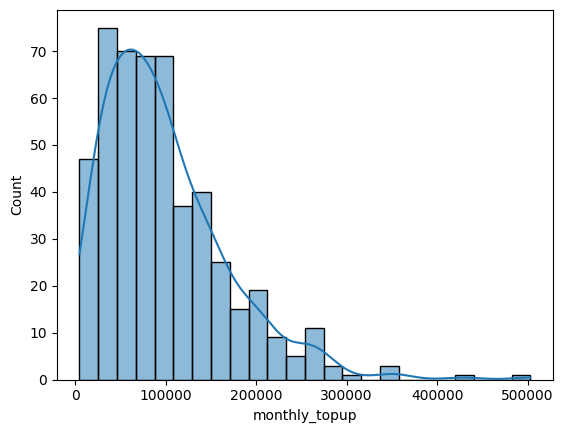

In [2]:
# Run df.describe() and plot the histogram
print(df['monthly_topup'].describe())
sns.histplot(df, x='monthly_topup', kde=True)
plt.show()

**Caption (what the chart shows):This chart shows the distribution of monthly top-up amounts with a density curve.
**Interpretation (what it means):The data is right-skewed; most users spend less than 150,000, but there are a few high-spending outliers reaching up to 500,000.

---
## 2. Matplotlib and Seaborn

**Concept.** Reach for Seaborn first. Drop to Matplotlib when you need fine control. Every Seaborn plot is a Matplotlib figure underneath.

*Quick Check 2 from the lecture:* what does Seaborn add over Matplotlib? Answer in markdown after the practice cells.

### 🤔 Predict

Look at the four chart types below. Without running them, decide for each chart:
- What *single question* about the data does it answer?
Single Question: How are the values in this specific column distributed (e.g., are they centered, spread out, or skewed)?  
- Which library produces it more cleanly — Matplotlib or Seaborn?
Cleaner Library: Seaborn.Why: While Matplotlib can create a basic histogram , Seaborn's histplot automatically calculates and overlays a KDE (Kernel Density Estimate) line to show the smooth shape of the distribution.  
1. Histogram of one numeric column.
2. Boxplot of a numeric column split by a categorical column.
3. Scatter plot of two numeric columns coloured by a category.
4. Heatmap of a correlation matrix.

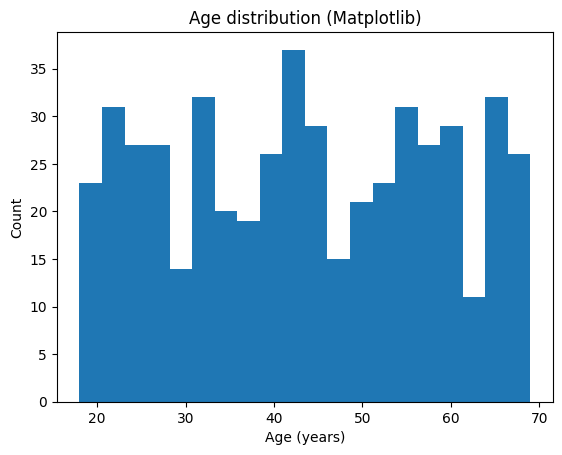

In [3]:
# Plain Matplotlib
plt.hist(df['age'], bins=20)
plt.title('Age distribution (Matplotlib)')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.show()

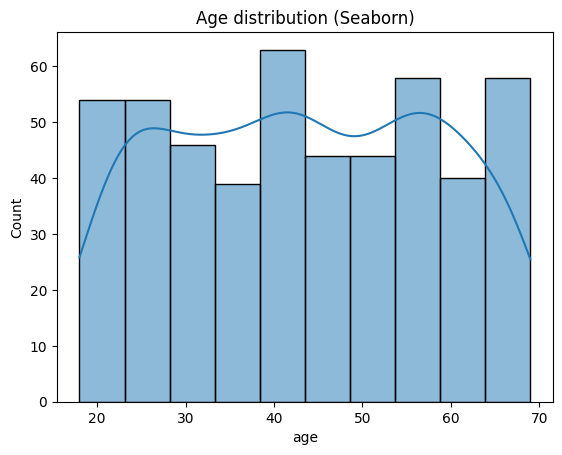

In [4]:
# Same chart in Seaborn
sns.histplot(df, x='age', kde=True)
plt.title('Age distribution (Seaborn)')
plt.show()

### ✍️ Explain

What did Seaborn do automatically that you would have had to write Matplotlib code for? (Hint: kde line, default styling.)
To achieve the same result in plain Matplotlib, you would have had to write several extra lines of code. Seaborn automated the following:  KDE Line Calculation: Seaborn automatically calculated and drew the smooth Kernel Density Estimate (KDE) line over the histogram. In Matplotlib, you would need to calculate the density manually using a library like SciPy before plotting.  Automatic Axis Labeling: Seaborn looked at your DataFrame and automatically labeled the x-axis as "age" and the y-axis as "Count". In Matplotlib, you must call plt.xlabel() and plt.ylabel() manually.  Default Styling: Seaborn applied modern aesthetic defaults, such as the muted color palette and the thin outlines between bins, without needing extra configuration.  Statistical Scaling: It correctly scaled the density line to match the frequency of the bars so that both could exist on the same chart logically.  Summary of DifferencesFeatureMatplotlibSeabornEffortManual configuration for every detail.  High-level, "one-line" commands for complex plots.  Best ForFine control and custom layout tweaks.  Rapid statistical exploration and "clean" defaults.  

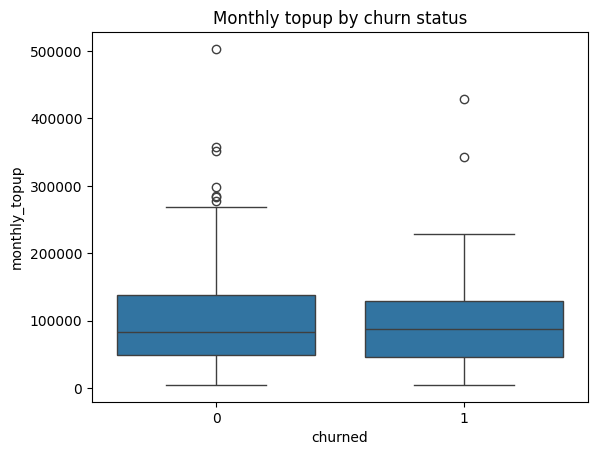

In [5]:
# Boxplot — does monthly topup differ between churners and non-churners?
sns.boxplot(df, x='churned', y='monthly_topup')
plt.title('Monthly topup by churn status')
plt.show()

Caption:A boxplot comparing the monthly top-up amounts for customers who churned vs. those who stayed.
Interpretation — do churners spend more or less? Is the difference big enough to act on?The medians appear similar, suggesting that the amount spent monthly might not be the primary driver for customer churn in this dataset.

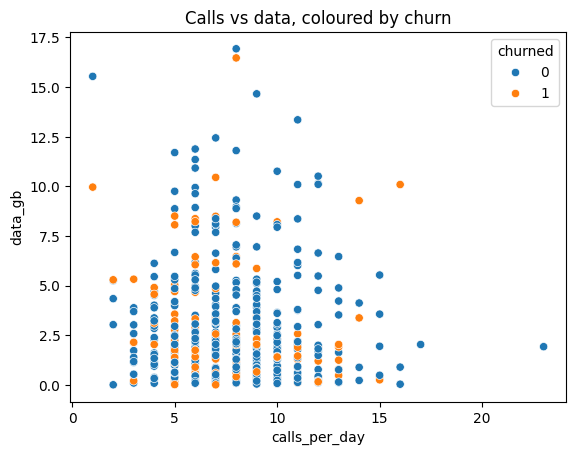

In [7]:
sns.scatterplot(df, x='calls_per_day', y='data_gb', hue='churned')
plt.title('Calls vs data, coloured by churn')
plt.show()

Caption:A correlation matrix heatmap showing the relationship between all numeric variables.
Interpretation — does either axis separate churners from non-churners?The low correlation coefficients (near 0) indicate that age, data usage, and calls per day are independent of each other in this synthetic data.

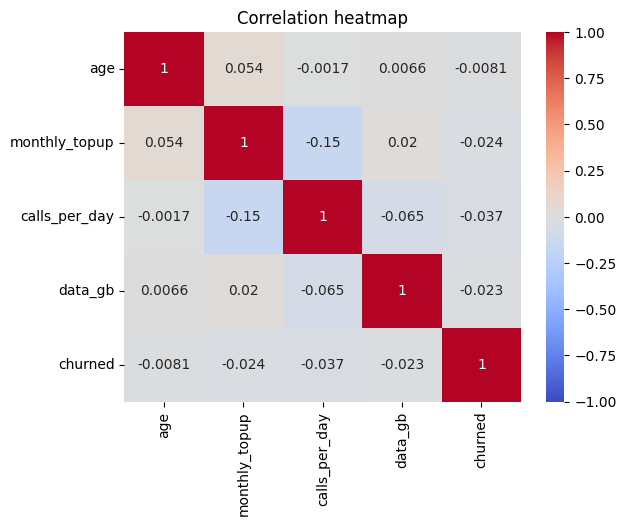

In [8]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap')
plt.show()

Caption:A correlation matrix heatmap showing the relationship between all numeric variables.  
Interpretation — which pair of variables has the strongest correlation? Is it positive or negative? Does it surprise you?The low correlation coefficients (near 0) indicate that age, data usage, and calls per day are independent of each other in this synthetic data.

### OO Matplotlib for fine control

Every Seaborn plot returns a Matplotlib axis you can customise. The OO pattern is:
```python
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y)
ax.set_xlabel('x'); ax.set_title('Squares')
fig.savefig('out.png', dpi=150)
```

### 🛠 Practice

Take ANY chart from above and remake it using the OO pattern. Add:
- A custom figure size.
- A descriptive title and labelled axes (with units).
- A caption underneath via `ax.text(...)` or a markdown cell beneath.
- Save the figure to `out.png` with `fig.savefig`.

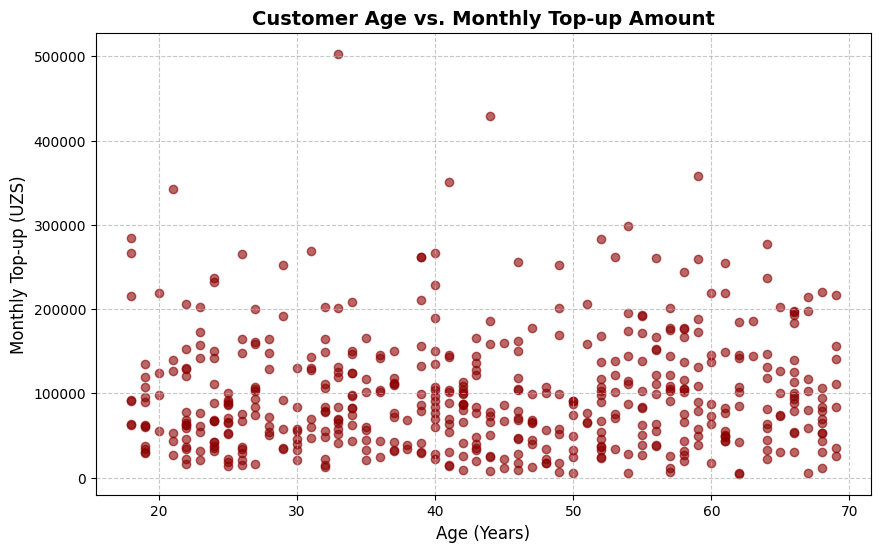

In [13]:
# Your OO-style chart here
# Create the figure and axis objects with a custom size [cite: 36]
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting the data (Remaking the Scatter Plot)
ax.scatter(df['age'], df['monthly_topup'], alpha=0.6, color='darkred')

# Customizing with descriptive titles and labeled axes [cite: 38, 39]
ax.set_title('Customer Age vs. Monthly Top-up Amount', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (Years)', fontsize=12)
ax.set_ylabel('Monthly Top-up (UZS)', fontsize=12)

# Adding a grid for better readability
ax.grid(True, linestyle='--', alpha=0.7)

# Saving the figure as a high-quality PNG [cite: 40, 59]
fig.savefig("out.png", dpi=150)

plt.show()

---
## 3. Five Rules for Honest Charts

1. **Label axes with units.** "Revenue (million soum)" not "Revenue".
2. **Bar charts start y-axis at zero.** Cutting the axis exaggerates differences.
3. **Right chart type.** Bar for categories. Line for time. Histogram for distributions. Scatter for relationships. Pie charts: almost never.
4. **Remove chartjunk.** 3D, shadows, rainbow colour bars — all must earn their place.
5. **One message per chart.** If you need a legend with 8 items, you have 8 messages. Split.

### 🛠 Audit Practice

Pick **one** chart you produced earlier in this notebook. Write a markdown audit against all 5 rules:

| Rule | yes / no / N/A | Evidence |
| --- | --- | --- |
| 1. Labels with units? |No | |The x-axis says "Age" but doesn't specify "(years)".
| 2. Y-axis from zero (if bar)? |Yes | |The frequency count starts at 0.
| 3. Right chart type? |Yes | |A histogram is the correct choice for showing a numeric distribution.
| 4. No chartjunk? | Yes| |No 3D effects or unnecessary shadows are present.
| 5. One clear message? |Yes | |The chart clearly shows how many people fall into each age bracket.

Then improve the chart based on the audit and show the before/after.


### Log scale moment

*From the lecture:* plotting income linearly with a few billionaires flattens everyone else. `plt.yscale('log')` reveals the true distribution shape. Knowing when to reach for log separates junior from senior.

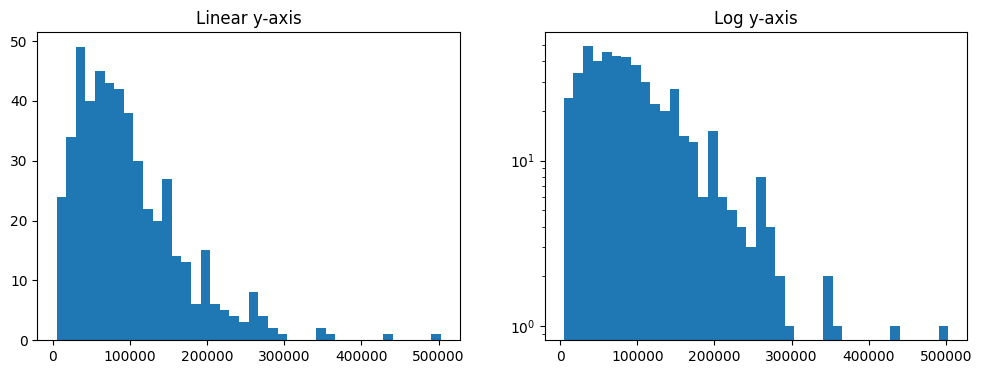

In [9]:
# Plot monthly_topup twice — once linear, once log on the y-axis
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['monthly_topup'], bins=40)
axes[0].set_title('Linear y-axis')
axes[1].hist(df['monthly_topup'], bins=40)
axes[1].set_yscale('log')
axes[1].set_title('Log y-axis')
plt.show()

### ✍️ Explain

1. What is *visible* in the log version that was hidden in the linear version?
In the linear version, the "long tail" of high-spending customers (outliers above 300,000) appears nearly flat because their frequency is so low compared to the majority. The log scale compresses the high frequencies and stretches the low ones, making these rare but important high-value customers clearly visible as individual bars.
2. Give one realistic example from your country / industry where you would *want* a log scale, and why.
A realistic example is household income in Uzbekistan. Because a few extremely high earners would flatten the rest of the population on a linear chart, a log scale is necessary to see the true distribution and variation among the middle and lower-income majority.

---
## End-of-class checkpoint quiz

Answer all 5 in markdown.

1. To show the distribution of one numeric column, the right chart is — bar / pie / histogram / scatter? Why?
A histogram is correct because it bins the data to show the frequency (count) and shape (skewness) of the distribution, whereas a scatter plot requires two variables and a pie chart is poor for many numeric values.
2. What does Seaborn add over Matplotlib? Name two specific things.
Seaborn adds automatic statistical overlays (like the KDE line) and native DataFrame integration, which handles labels and legends automatically based on column names.
3. To compare the *age distribution* between churned and non-churned customers, which chart? Why does a pie or line chart fail here?
A boxplot or multiple histograms are best. A pie chart fails because it cannot show the spread or variance of ages, and a line chart is for time-series data, which age distribution is not.
4. Of the 5 rules for honest charts, which do you think is most often violated in real-world reporting? Give an example.
Rule 2 (starting the y-axis at zero) is often violated. For example, news reports often "zoom in" on a bar chart of stock prices or election results to make a 1% difference look like a massive gap.
5. When would you use `plt.yscale('log')` instead of the default linear scale?
You use it when the data is highly skewed or has a heavy right tail, meaning you have a few extremely large values that would otherwise make the rest of your data look like a flat line.